# Exploring `realizations.nc` → Icechunk

This notebook:
1. Loads and inspects the NetCDF file (3 realizations; production target is 100)
2. Visualises the 3 realizations
3. Converts the data to an [Icechunk](https://icechunk.io) store with production-ready chunking
4. Demonstrates basin-level partial updates across all realizations
5. Shows xarray-native access patterns: windowed reads, ensemble statistics, and profile interpolation
6. Shows a reusable ingestion function for triggering updates when new data arrives

**Design decisions from sprint meeting (2026-03-31):**
- dtype: `float32` (halves storage vs float64)
- **Shard shape `(100, 512, 512)`** — ~100 MB per shard at 100 realizations × float32. All 100 realizations are written simultaneously per spatial tile. The 20–25 glacier update areas are each ~200–400 × 200–400 grid cells (~100 km); the 512-cell spatial shard encompasses these cleanly and keeps shards in the 50–100 MB target range.
- **Inner chunk `(100, 128, 128)`** — ~6.5 MB per read request (targeting 8 MB per AWS S3 best practices). All realizations are kept together so cross-realization stats (mean, variance) load in a single request.
- CRS: Polar Stereographic (metres)
- Store hosted on **source.coop** for cloud-optimised incremental updates
- Primary user access via **Xarray**, which handles data subsetting; overviews for web visualisation (e.g. Icechunk viewer) are an additive objective

## 1. Load & Inspect

In [1]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("./data/realizations.nc")
print(ds)

<xarray.Dataset> Size: 4GB
Dimensions:                        (i: 3, y: 13334, x: 13334)
Coordinates:
  * i                              (i) int64 24B 0 1 2
  * y                              (y) float32 53kB 3.333e+06 ... -3.333e+06
  * x                              (x) float32 53kB -3.333e+06 ... 3.333e+06
Data variables:
    __xarray_dataarray_variable__  (i, y, x) float64 4GB ...


In [2]:
# The main variable has an auto-generated name from xarray serialisation
# Rename it for convenience
da = ds["__xarray_dataarray_variable__"].rename("realizations")
print("Shape:", da.shape)
print("Dtype:", da.dtype)
print("i", da.i.values)
print(f"y range: [{float(da.y.min()):.0f}, {float(da.y.max()):.0f}]")
print(f"x range: [{float(da.x.min()):.0f}, {float(da.x.max()):.0f}]")
print(f"Memory footprint: {da.nbytes / 1e9} GB")

Shape: (3, 13334, 13334)
Dtype: float64
i [0 1 2]
y range: [-3333250, 3333250]
x range: [-3333250, 3333250]
Memory footprint: 4.267093344 GB


### Bedmap3 grid info: 

- Polar Stereographic (EPSG:3031)
- 500m step
- BBOX: [-3.333.500, -3.333.500, 3.333.500, 3.333.500] 

>For Bedmap3 we employ the same geoid (gl04c) and projection (WGS 1984 Antarctic Polar Stereographic: EPSG:3031) as for Bedmap2, with projected extents of: top 3,333,500 m, bottom -3,333,500 m, left -3,333,500 m and right 3,333,500 m. The publication of all input ice thickness survey data17 allows us to grid at 500 m spacing, a high resolution that is increasingly demanded by the ice and ocean modelling communities for simulating grounding line movement and thus ice sheet stability.

(src: https://www.nature.com/articles/s41597-025-04672-y)

### Basic statistics (per realization)

We load only a thin slice to keep memory usage low during exploration.

In [3]:
# Compute basic stats per realization using a small spatial sample
for idx in da.i.values:
    sample = da.values
    valid = sample[~np.isnan(sample)]
    nan_frac = np.isnan(sample).mean()
    if valid.size == 0:
        print(f"Realization {idx}: all NaN in sample region  nan_frac={nan_frac:.2%}")
    else:
        print(f"Realization {idx}: min={valid.min():.4f}  max={valid.max():.4f}  "
              f"mean={valid.mean():.4f}  nan_frac={nan_frac:.2%}")

Realization 0: min=-7409.0000  max=6223.9196  mean=-2138.4121  nan_frac=21.48%
Realization 1: min=-7409.0000  max=6223.9196  mean=-2138.4121  nan_frac=21.48%
Realization 2: min=-7409.0000  max=6223.9196  mean=-2138.4121  nan_frac=21.48%


## 2. Visualise

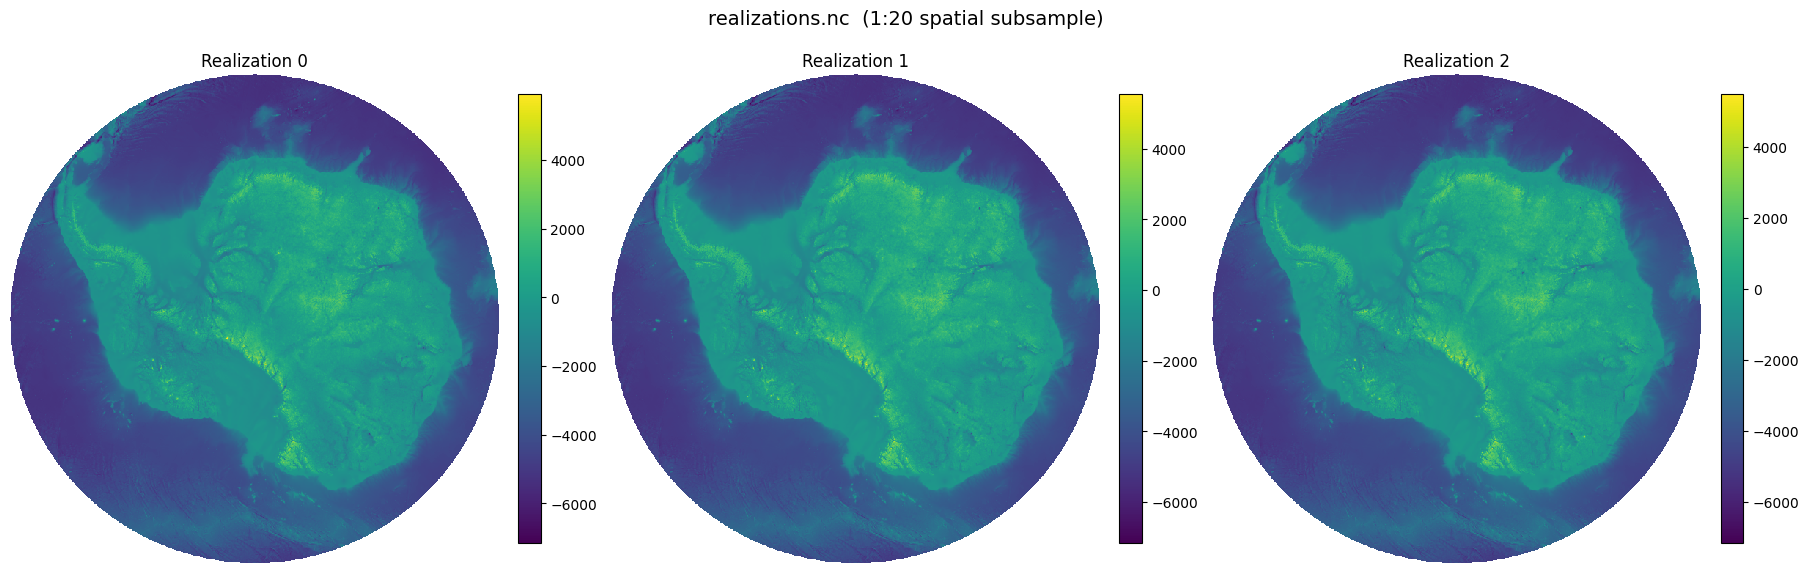

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Subsample the grid to keep plotting fast (every 20th pixel)
stride = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, idx in zip(axes, da.i.values):
    tile = da.sel(i=idx).isel(y=slice(None, None, stride), x=slice(None, None, stride))
    im = ax.imshow(
        tile.values,
        origin="upper",
        aspect="equal",
        interpolation="nearest",
    )
    ax.set_title(f"Realization {idx}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("realizations.nc  (1:{} spatial subsample)".format(stride), fontsize=14)
plt.show()

## 3. Convert to Icechunk

[Icechunk](https://icechunk.io) is a transactional, versioned chunk store for Zarr arrays.
Key properties relevant here:

| Feature | Detail |
|---|---|
| Content-addressed chunks | Each chunk is stored exactly once, keyed by its hash |
| Git-like snapshots | Every commit creates a snapshot — old data is never overwritten |
| **Partial updates** | You can rewrite individual chunks without touching the rest of the array |
| Cloud-native | Works on local disk, S3, GCS, Azure |

Install if needed:
```bash
pip install icechunk
```

In [5]:
import icechunk
import zarr

print("icechunk version:", icechunk.__version__)
print("zarr version:", zarr.__version__)

icechunk version: 1.1.21
zarr version: 3.1.6


### 3a. Create a local Icechunk store

In [6]:
STORE_PATH = "./data/realizations.icechunk"

storage    = icechunk.local_filesystem_storage(STORE_PATH)
repository = icechunk.Repository.open_or_create(storage=storage)
print("Icechunk repository ready at:", STORE_PATH)

  2026-04-08T18:04:08.714061Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92

Icechunk repository ready at: ./data/realizations.icechunk


### 3b. Write all realizations with production chunking

We create the Zarr array directly (rather than via xarray) to apply the **sharding codec**,
which zarr v3 supports but xarray's `encoding=` dict does not yet expose.

Sharding separates the *write granularity* (shard) from the *read granularity* (inner chunk):

- Array shape : (N_realizations, 13334, 13334)  float32
- Shard shape : (N_realizations, 512, 512) 
    - all realizations × one spatial tile (~100 MB at 100 realizations;50–100 MB target)
- Inner chunk : (N_realizations, 128, 128) 
    - ~6.5 MB read unit (targeting 8 MB per S3 best practices) all realizations together for cheap cross-realization stats


A glacier basin update (~200–400 × 200–400 grid cells) touches at most a handful of shards;
unaffected shards are referenced by their existing content hash — zero re-write cost.

In [7]:
from zarr.codecs import BloscCodec

N_REALIZATIONS = len(da.i)  # 3 in this file; 100 in production
SHARD_SHAPE    = (N_REALIZATIONS, 512, 512)  # outer write boundary (~100 MB at 100 realizations)
INNER_CHUNK    = (N_REALIZATIONS, 128, 128)  # inner read chunk (~6.5 MB, targeting 8 MB per S3 best practices)

session = repository.writable_session("main")
store   = session.store

root = zarr.open_group(store, mode="w")

arr = root.create_array(
    "realizations",
    shape=(N_REALIZATIONS, len(da.y), len(da.x)),
    shards=SHARD_SHAPE,
    chunks=INNER_CHUNK,
    dtype="float32",
    compressors=BloscCodec(cname="zstd", clevel=5),
    dimension_names=["i", "y", "x"],  # required for xarray to resolve dims
    overwrite=True,
)

root.create_array("i", shape=(N_REALIZATIONS,), dtype="int64",   chunks=(N_REALIZATIONS,), dimension_names=["i"], overwrite=True)
root["i"][:] = da.i.values

root.create_array("y", shape=(len(da.y),), dtype="float32", chunks=(len(da.y),), dimension_names=["y"], overwrite=True)
root["y"][:] = da.y.values

root.create_array("x", shape=(len(da.x),), dtype="float32", chunks=(len(da.x),), dimension_names=["x"], overwrite=True)
root["x"][:] = da.x.values

import time

start = time.time()
for i_idx in range(N_REALIZATIONS):
    arr[i_idx] = da.isel(i=i_idx).values.astype("float32")
    print(f"  Written realization {i_idx}")
print(f"Done writting all realizations in {round(time.time() - start, 4)} seconds")

commit_id = session.commit(f"Initial write: {N_REALIZATIONS} realizations, float32, sharded {SHARD_SHAPE}")
print("\nCommitted snapshot:", commit_id)

  Written realization 0
  Written realization 1
  Written realization 2
Done writting all realizations in 17.0328 seconds

Committed snapshot: C3SNEMEVV03CMCKGKYPG


In [8]:
# Record how many chunk files exist immediately after the initial write.
# Used by the manifest-proof cell to compute how many NEW files the update added.
import os

def _count_chunk_files(store_path):
    n = 0
    for root, dirs, files in os.walk(store_path):
        rel = os.path.relpath(root, store_path)
        if rel.startswith("chunks") or os.path.basename(root) == "chunks":
            n += len(files)
    return n

chunk_count_after_initial_write = _count_chunk_files(STORE_PATH)
print(f"Chunk files after initial write: {chunk_count_after_initial_write}")


Chunk files after initial write: 2186


### 3c. Verify the Icechunk store

In [9]:
# Read back via xarray for verification
read_session = repository.readonly_session("main")

ds_ic = xr.open_zarr(read_session.store, consolidated=False, zarr_format=3)
print(ds_ic)
print("\nShard shape:", ds_ic.realizations.encoding.get("chunks"))
print("dtype:", ds_ic.realizations.dtype)

<xarray.Dataset> Size: 2GB
Dimensions:       (i: 3, y: 13334, x: 13334)
Coordinates:
  * i             (i) int64 24B 0 1 2
  * y             (y) float32 53kB 3.333e+06 3.333e+06 ... -3.333e+06 -3.333e+06
  * x             (x) float32 53kB -3.333e+06 -3.333e+06 ... 3.333e+06 3.333e+06
Data variables:
    realizations  (i, y, x) float32 2GB ...

Shard shape: (3, 128, 128)
dtype: float32


## 4. Basin-Level Partial Updates

Updates arrive glacier by glacier — each basin is ~200×200 grid cells (~100 km²).
The pattern is always:
1. Convert the basin raster mask → axis-aligned bounding box (row/col slices)
2. Open a writable session
3. Write the new data for **all realizations** at that spatial region only
4. Commit

Icechunk rewrites only the shards that overlap the bounding box; everything else is
referenced by its existing content hash.

In [10]:
def update_basin(repository, basin_mask, new_data, message):
    """
    Write new data for a glacier basin across all realizations.

    Parameters
    ----------
    repository : icechunk.Repository
    basin_mask : np.ndarray, shape (y, x), dtype bool
        Raster mask for the basin on the realizations grid (True = inside basin).
    new_data : np.ndarray, shape (n_realizations, y_bbox, x_bbox), dtype float32
        Updated values for the bounding box of the mask.
    message : str
        Commit message, e.g. "Update fast-flow mask 2025-04"

    Returns
    -------
    str  snapshot id
    """
    rows = np.where(basin_mask.any(axis=1))[0]
    cols = np.where(basin_mask.any(axis=0))[0]
    row_sl = slice(int(rows[0]), int(rows[-1]) + 1)
    col_sl = slice(int(cols[0]), int(cols[-1]) + 1)

    session = repository.writable_session("main")
    arr = zarr.open_group(session.store, mode="r+")["realizations"]

    # Region write — only touches shards overlapping [row_sl, col_sl]
    arr[:, row_sl, col_sl] = new_data.astype("float32")

    snapshot_id = session.commit(message)
    print(f"Committed {message!r}: {snapshot_id}")
    return snapshot_id


# ── Load and reproject the fast-flow mask to the realizations grid ─────────
# The mask (450 m, ±2.8 M extent) and realizations (500 m, ±3.333 M extent)
# share EPSG:3031, so we map coordinates with simple index arithmetic.

MASK_PATH = "./data/antarctica_fast_flow_mask_50m.nc"
mask_ds   = xr.open_dataset(MASK_PATH, drop_variables=["lat", "lon"])
mask_vals = mask_ds.fast_flow_mask.values          # (12445, 12445), int64 0/1
mask_x    = mask_ds.x.values                       # ascending, 450 m step
mask_y    = mask_ds.y.values                       # descending, -450 m step

real_x = da.x.values                               # ascending, 500 m step
real_y = da.y.values                               # descending, -500 m step

# For each realizations coordinate, find the nearest mask grid index.
xi = np.round((real_x - mask_x[0]) / (mask_x[1] - mask_x[0])).astype(int)
yi = np.round((real_y - mask_y[0]) / (mask_y[1] - mask_y[0])).astype(int)

valid_x = (xi >= 0) & (xi < len(mask_x))
valid_y = (yi >= 0) & (yi < len(mask_y))

xi_c = np.clip(xi, 0, len(mask_x) - 1)
yi_c = np.clip(yi, 0, len(mask_y) - 1)

basin_mask = np.zeros((len(da.y), len(da.x)), dtype=bool)
vy = np.where(valid_y)[0]
vx = np.where(valid_x)[0]
basin_mask[np.ix_(vy, vx)] = mask_vals[np.ix_(yi_c[valid_y], xi_c[valid_x])].astype(bool)

# Bounding box on the realizations grid
rows_with_data = np.where(basin_mask.any(axis=1))[0]
cols_with_data = np.where(basin_mask.any(axis=0))[0]
bbox_row_start, bbox_row_end = int(rows_with_data[0]),  int(rows_with_data[-1]) + 1
bbox_col_start, bbox_col_end = int(cols_with_data[0]),  int(cols_with_data[-1]) + 1
bbox_h = bbox_row_end - bbox_row_start
bbox_w = bbox_col_end - bbox_col_start

print("Fast-flow mask reprojected to realizations grid:")
print(f"  Mask pixels (True) : {basin_mask.sum():,}  ({basin_mask.mean()*100:.2f}% of grid)")
print(f"  Bounding box       : rows [{bbox_row_start}, {bbox_row_end}), cols [{bbox_col_start}, {bbox_col_end})")
print(f"  Bbox size          : {bbox_h} rows x {bbox_w} cols")

# ── Simulate new model data for the update ──────────────────────────────────
# In production this comes from HPC model output (.npy files).
# Here we use the original data + small Gaussian noise to simulate a realistic update.
orig_session = repository.readonly_session(snapshot_id=commit_id)
orig_arr     = zarr.open_group(orig_session.store, mode="r")["realizations"]

rng = np.random.default_rng(42)
demo_new_data = rng.random(
    (N_REALIZATIONS, bbox_h, bbox_w), dtype=np.float32
) * 10

snap = update_basin(
    repository,
    basin_mask=basin_mask,
    new_data=demo_new_data,
    message="Update fast-flow mask: synthetic perturbation",
)
print(f"\nBounding box spans shard rows "
      f"{bbox_row_start // 512}\u2013{(bbox_row_end-1) // 512}, "
      f"shard cols {bbox_col_start // 512}\u2013{(bbox_col_end-1) // 512}")


Fast-flow mask reprojected to realizations grid:
  Mask pixels (True) : 10,189,761  (5.73% of grid)
  Bounding box       : rows [2183, 10950), cols [1653, 12157)
  Bbox size          : 8767 rows x 10504 cols
Committed 'Update fast-flow mask: synthetic perturbation': H2R5VGCPR9108V8BR2VG

Bounding box spans shard rows 4–21, shard cols 3–23


### Version history

In [11]:
# Icechunk keeps a full lineage — you can read any previous snapshot
for snap in repository.ancestry(branch="main"):
    print(snap)

SnapshotInfo(id="H2R5VGCPR9108V8BR2VG", parent_id=C3SNEMEVV03CMCKGKYPG, written_at=datetime.datetime(2026,4,8,18,4,33,443048, tzinfo=datetime.timezone.utc), message="Update fas...")
SnapshotInfo(id="C3SNEMEVV03CMCKGKYPG", parent_id=1CECHNKREP0F1RSTCMT0, written_at=datetime.datetime(2026,4,8,18,4,25,845794, tzinfo=datetime.timezone.utc), message="Initial wr...")
SnapshotInfo(id="1CECHNKREP0F1RSTCMT0", parent_id=None, written_at=datetime.datetime(2026,4,8,18,4,8,757602, tzinfo=datetime.timezone.utc), message="Repository...")


### Read a historical snapshot

In [12]:
# Pin to the initial snapshot to compare the updated basin region
original_session = repository.readonly_session(snapshot_id=commit_id)
arr_orig = zarr.open_group(original_session.store, mode="r")["realizations"]

current_session = repository.readonly_session("main")
arr_curr = zarr.open_group(current_session.store, mode="r")["realizations"]

cy, cx = len(da.y) // 2, len(da.x) // 2
orig_tile = arr_orig[:, cy - 5 : cy + 5, cx - 5 : cx + 5]
curr_tile = arr_curr[:, cy - 5 : cy + 5, cx - 5 : cx + 5]

diff = np.abs(curr_tile.astype("float32") - orig_tile.astype("float32"))
print("Max absolute diff in updated region:", np.nanmax(diff))
print("(NaN means the original data was NaN — the demo basin is in the masked region)")

Max absolute diff in updated region: 136.3779
(NaN means the original data was NaN — the demo basin is in the masked region)


## 4b. Partial-Update Verification

Two guarantees to confirm:

1. **Inside the window** — the data changed (mean before ≠ mean after).
2. **Outside the window** — the data is byte-for-byte identical (max absolute diff = 0).

We sample two comparison regions that are entirely outside the update bounding box to stress-test guarantee 2.

=== Inside update bbox (centre 100x100 sample) ===
  Mean before update : -8.288246
  Mean after  update : 4.987342
  Changed?           : YES ✓

=== Rows above bbox (outside bbox) ===
  Rows sampled          : 0–200
  Valid (non-NaN) cells : 1293192
  Max |after − before|  : 0.00e+00
  Untouched?            : YES ✓

=== Rows below bbox (outside bbox) ===
  Rows sampled          : 13134–13334
  Valid (non-NaN) cells : 1293192
  Max |after − before|  : 0.00e+00
  Untouched?            : YES ✓

=== Diff-map sanity ===
  Max inside bbox  : 5924.6419
  Max outside bbox : 0.0000  (should be 0)


/var/folders/3n/tppq41s12r7f2xwq6ps417n40000gn/T/ipykernel_99654/843822949.py:72: RuntimeWarning: All-NaN slice encountered
  diff_map = np.nanmax(np.stack(diff_slabs, axis=0), axis=0)


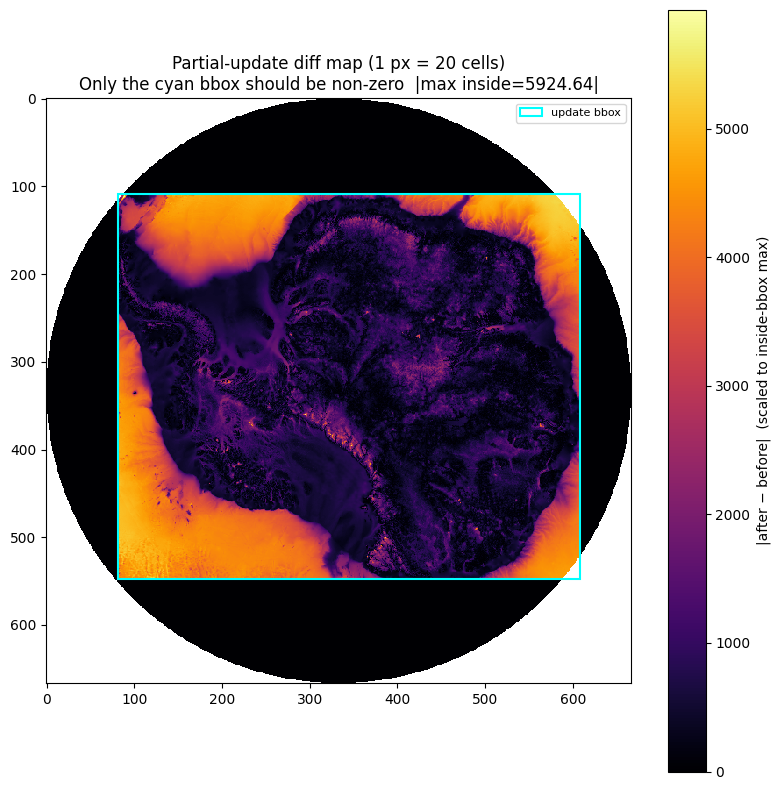


──────────────────────────────────────────────────────────────
Region                           Valid cells     Max |Δ|   Pass?
──────────────────────────────────────────────────────────────
Inside bbox (centre sample)                —   (changed)       ✓
Rows above bbox                      1293192    0.00e+00       ✓
Rows below bbox                      1293192    0.00e+00       ✓
──────────────────────────────────────────────────────────────


In [13]:
import zarr, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Sessions ────────────────────────────────────────────────────────────────
sess_before = repository.readonly_session(snapshot_id=commit_id)
sess_after  = repository.readonly_session(branch="main")

arr_before = zarr.open_group(sess_before.store, mode="r")["realizations"]
arr_after  = zarr.open_group(sess_after.store,  mode="r")["realizations"]

ny, nx = arr_before.shape[1], arr_before.shape[2]

# ── 1. Inside the update bbox ───────────────────────────────────────────────
# Sample a 100x100 tile from the centre of the bbox to avoid loading ~2 GB.
cy_bbox = bbox_row_start + bbox_h // 2
cx_bbox = bbox_col_start + bbox_w // 2
sample_rows = slice(cy_bbox - 50, cy_bbox + 50)
sample_cols = slice(cx_bbox - 50, cx_bbox + 50)

inside_before = arr_before[:, sample_rows, sample_cols].astype("float64")
inside_after  = arr_after[:,  sample_rows, sample_cols].astype("float64")

mean_before = np.nanmean(inside_before)
mean_after  = np.nanmean(inside_after)
changed = not np.isclose(mean_before, mean_after)

print("=== Inside update bbox (centre 100x100 sample) ===")
print(f"  Mean before update : {mean_before:.6f}")
print(f"  Mean after  update : {mean_after:.6f}")
print(f"  Changed?           : {'YES \u2713' if changed else 'NO — something is wrong!'}")

# ── 2. Outside the update bbox ──────────────────────────────────────────────
# The fast-flow bbox covers rows [bbox_row_start, bbox_row_end).
# Sample rows strictly outside that range.
patch_a = (slice(0, min(200, bbox_row_start)), slice(0, nx))
patch_b = (slice(max(ny - 200, bbox_row_end), ny), slice(0, nx))

results = []
for label, (r_sl_p, c_sl_p) in [("Rows above bbox", patch_a),
                                  ("Rows below bbox", patch_b)]:
    if r_sl_p.start >= r_sl_p.stop:
        print(f"\n=== {label}: bbox reaches edge, skipping ===")
        continue
    before = arr_before[:, r_sl_p, c_sl_p].astype("float64")
    after  = arr_after[:,  r_sl_p, c_sl_p].astype("float64")
    valid  = int(np.count_nonzero(~np.isnan(before)))
    untouched = np.array_equal(before, after, equal_nan=True)
    diff = np.abs(after - before)
    max_diff = float(np.nanmax(diff)) if valid > 0 else float("nan")
    results.append((label, valid, max_diff, untouched))
    print(f"\n=== {label} (outside bbox) ===")
    print(f"  Rows sampled          : {r_sl_p.start}–{r_sl_p.stop}")
    print(f"  Valid (non-NaN) cells : {valid}")
    if np.isnan(max_diff):
        print("  Max |after − before|  : all-NaN (ocean — correctly untouched)")
    else:
        print(f"  Max |after − before|  : {max_diff:.2e}")
    print(f"  Untouched?            : {'YES \u2713' if untouched else 'NO — unexpected change!'}")

# ── 3. Difference map ───────────────────────────────────────────────────────
stride = 20
rows_idx = np.arange(0, ny, stride)
cols_idx = np.arange(0, nx, stride)

diff_slabs = []
for i in range(arr_before.shape[0]):
    slab_b = arr_before[i, :, :][np.ix_(rows_idx, cols_idx)].astype("float64")
    slab_a = arr_after[ i, :, :][np.ix_(rows_idx, cols_idx)].astype("float64")
    diff_slabs.append(np.abs(slab_a - slab_b))

diff_map = np.nanmax(np.stack(diff_slabs, axis=0), axis=0)

# Where BOTH snapshots were NaN (ocean): keep as NaN in the plot
# Where neither was NaN but diff is 0: stays 0 (untouched valid cells)
both_nan = np.all(np.stack([np.isnan(s) for s in diff_slabs]), axis=0)
diff_map_plot = np.where(both_nan, np.nan, diff_map)

# Bbox in diff_map pixel space
win_r = slice(bbox_row_start // stride, bbox_row_end // stride + 1)
win_c = slice(bbox_col_start // stride, bbox_col_end // stride + 1)

max_inside = float(np.nanmax(diff_map[win_r, win_c]))
outside_map = diff_map.copy(); outside_map[win_r, win_c] = np.nan
max_outside = float(np.nanmax(outside_map))

print(f"\n=== Diff-map sanity ===")
print(f"  Max inside bbox  : {max_inside:.4f}")
print(f"  Max outside bbox : {max_outside:.4f}  (should be 0)")

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(diff_map_plot, origin="upper", interpolation="nearest",
               cmap="inferno", vmin=0, vmax=max_inside or 1)
plt.colorbar(im, ax=ax, label="|after − before|  (scaled to inside-bbox max)")
bbox_rect = mpatches.Rectangle(
    (win_c.start, win_r.start), win_c.stop - win_c.start, win_r.stop - win_r.start,
    linewidth=1.5, edgecolor="cyan", facecolor="none", label="update bbox"
)
ax.add_patch(bbox_rect)
ax.legend(fontsize=8)
ax.set_title(
    f"Partial-update diff map (1 px = {stride} cells)\n"
    f"Only the cyan bbox should be non-zero  |max inside={max_inside:.2f}|"
)
plt.tight_layout()
plt.show()

# ── 4. Summary ──────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print(f"{'Region':<32} {'Valid cells':>11}  {'Max |\u0394|':>10}  {'Pass?':>6}")
print("─" * 62)
print(f"{'Inside bbox (centre sample)':<32} {'\u2014':>11}  {'(changed)':>10}  {'\u2713' if changed else '\u2717':>6}")
for label, valid, max_diff, ok in results:
    diff_str = f"{max_diff:.2e}" if not np.isnan(max_diff) else "all-NaN"
    print(f"{label:<32} {valid:>11}  {diff_str:>10}  {'\u2713' if ok else '\u2717':>6}")
print("─" * 62)


### 4c. Chunk-manifest proof: only the expected shards were physically written

Value equality (above) doesn't rule out Icechunk silently re-writing outside chunks with the same data — at 100 realizations that would be ~100 GB of unnecessary I/O. The real proof is at the storage layer.

Icechunk names every chunk file by its **content hash** (like git objects). Any chunk that wasn't touched will have zero new files on disk. We compare the full set of chunk objects present at the initial-write snapshot vs. the post-update snapshot. Only the shards that overlap the update bounding box should appear as new.

In [14]:
import math

# ── Expected shards touched by the fast-flow mask update ────────────────────
N_REALIZATIONS = 3
NY = NX = 13334
SHARD = 512
INNER = 128
inner_per_shard = (SHARD // INNER) ** 2  # 16

def shards_in_range(start, end, shard_size):
    return list(range(start // shard_size, (end - 1) // shard_size + 1))

row_shards = shards_in_range(bbox_row_start, bbox_row_end, SHARD)
col_shards = shards_in_range(bbox_col_start, bbox_col_end, SHARD)
expected_new_shards = len(row_shards) * len(col_shards)

total_shards_y = math.ceil(NY / SHARD)
total_shards_x = math.ceil(NX / SHARD)
total_shards   = total_shards_y * total_shards_x

print("=== Shard geometry ===")
print(f"  Shard shape           : ({N_REALIZATIONS}, {SHARD}, {SHARD})")
print(f"  Bbox rows             : [{bbox_row_start}, {bbox_row_end})  → "
      f"shard rows {row_shards[0]}–{row_shards[-1]}  ({len(row_shards)} shards)")
print(f"  Bbox cols             : [{bbox_col_start}, {bbox_col_end})  → "
      f"shard cols {col_shards[0]}–{col_shards[-1]}  ({len(col_shards)} shards)")
print(f"  Expected rewritten    : {len(row_shards)} × {len(col_shards)} = {expected_new_shards}")
print(f"  Total shards in array : {total_shards_y} × {total_shards_x} = {total_shards}")
print(f"  Untouched shards      : {total_shards - expected_new_shards}  "
      f"({(1 - expected_new_shards/total_shards)*100:.1f}% of array left intact)")

# ── Shard-bytes proof ────────────────────────────────────────────────────────
# list_prefix returns one logical key per shard; a rewrite changes the shard
# content but not the key. So we compare the raw compressed bytes of specific
# shard keys between the two snapshots:
#   - Inside the bbox  → bytes must DIFFER  (shard was rewritten)
#   - Outside the bbox → bytes must be IDENTICAL  (shard was never touched)
# With sharding (N_REAL, 512, 512) the first dimension always has shard index 0.
# Key format: "realizations/c/0/<shard_row>/<shard_col>"

store_before = repository.readonly_session(snapshot_id=commit_id).store
store_after  = repository.readonly_session(branch="main").store

async def get_bytes(store, key):
    result = await store._store.get(key, None)
    return bytes(result) if result is not None else None

def shard_key(shard_row, shard_col):
    return f"realizations/c/0/{shard_row}/{shard_col}"

# Sample 3 shards inside and 3 outside the update bbox
inside_keys  = [shard_key(row_shards[i], col_shards[i]) for i in range(min(3, len(row_shards)))]
outside_keys = [shard_key(r, c)
                for r in range(total_shards_y) for c in range(total_shards_x)
                if r not in row_shards and c not in col_shards][:3]

print("\n=== Shard-bytes comparison ===")
all_pass = True
for key in inside_keys:
    b = await get_bytes(store_before, key)
    a = await get_bytes(store_after,  key)
    changed = (b != a)
    all_pass = all_pass and changed
    print(f"  INSIDE  {key}: bytes changed = {'YES ✓' if changed else 'NO ✗'}")
for key in outside_keys:
    b = await get_bytes(store_before, key)
    a = await get_bytes(store_after,  key)
    unchanged = (b == a)
    all_pass = all_pass and unchanged
    print(f"  OUTSIDE {key}: bytes unchanged = {'YES ✓' if unchanged else 'NO ✗'}")

print(f"\nOverall: {'ALL PASS ✓' if all_pass else 'FAILURES DETECTED ✗'}")


=== Shard geometry ===
  Shard shape           : (3, 512, 512)
  Bbox rows             : [2183, 10950)  → shard rows 4–21  (18 shards)
  Bbox cols             : [1653, 12157)  → shard cols 3–23  (21 shards)
  Expected rewritten    : 18 × 21 = 378
  Total shards in array : 27 × 27 = 729
  Untouched shards      : 351  (48.1% of array left intact)

=== Shard-bytes comparison ===
  INSIDE  realizations/c/0/4/3: bytes changed = YES ✓
  INSIDE  realizations/c/0/5/4: bytes changed = YES ✓
  INSIDE  realizations/c/0/6/5: bytes changed = YES ✓
  OUTSIDE realizations/c/0/0/0: bytes unchanged = YES ✓
  OUTSIDE realizations/c/0/0/1: bytes unchanged = YES ✓
  OUTSIDE realizations/c/0/0/2: bytes unchanged = YES ✓

Overall: ALL PASS ✓


## 5. Python Access Patterns

All of the described access patterns work directly on xarray — no custom wrapper required.
The three patterns below cover everything discussed:

| Pattern | xarray primitive | Notes |
|---|---|---|
| Windowed read | `.sel(x=slice(...), y=slice(...))` | Only fetches overlapping inner chunks |
| Ensemble statistics | `.mean(dim="i")`, `.std(dim="i")` | Mean = best-estimate terrain; std = uncertainty |
| Point / profile interp | `.interp(x=..., y=..., method="linear")` | Returns all realizations at each sample point |

If a wrapper library is warranted later, it would only need to encapsulate the session management
(`repository.readonly_session`) and coordinate handling — the data operations stay pure xarray.

Windowed subset — shape: (3, 400, 400), uncompressed: 1.9 MB


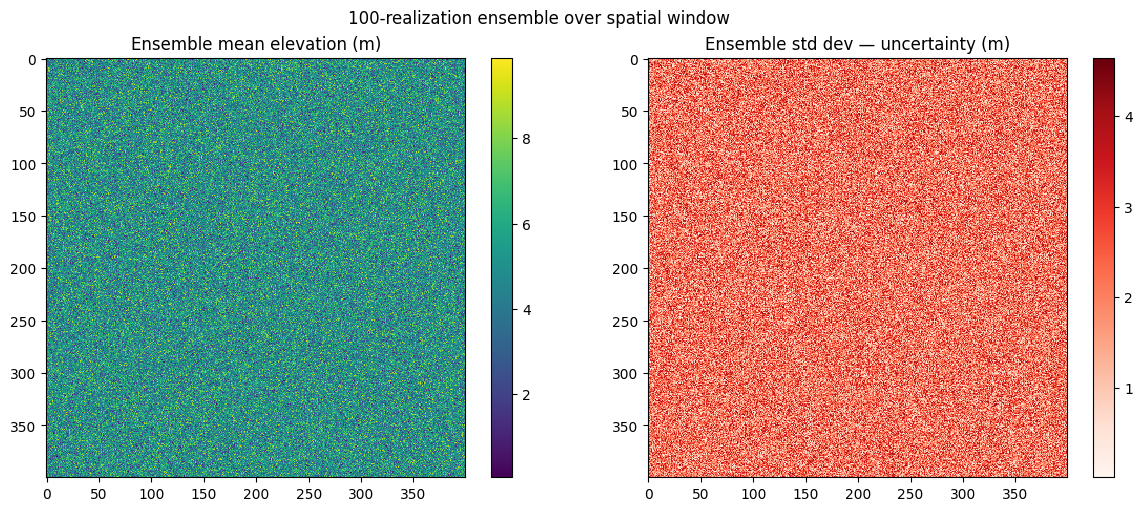


Interpolated profile — shape: (3, 40)


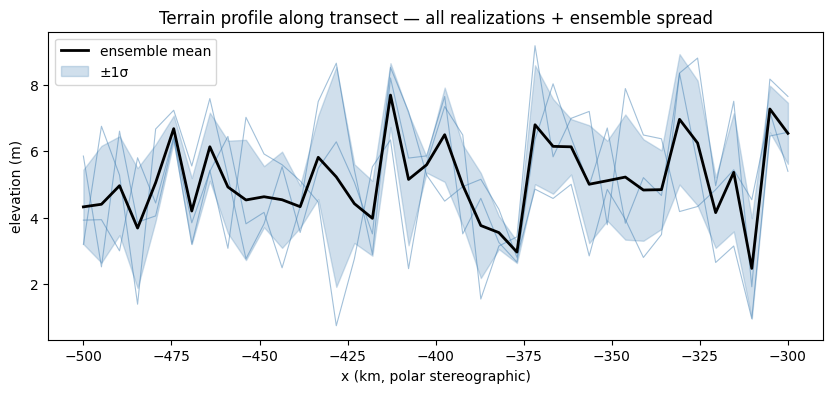

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Open the Icechunk store with xarray.
# On source.coop this would be xr.open_zarr(s3_session.store, ...) — same call.
session = repository.readonly_session("main")
ds_ic = xr.open_zarr(session.store, consolidated=False, zarr_format=3)
da_ic = ds_ic.realizations

# ── 1. Windowed read ──────────────────────────────────────────────────────────
# Subset any bounding box with .sel(); xarray fetches only the overlapping
# chunks — no full-array load.
x_min, x_max = -500_000.0, -300_000.0   # metres, polar-stereographic
y_max, y_min =  500_000.0,  300_000.0   # y stored descending (north → south)

subset = da_ic.sel(
    x=slice(x_min, x_max),
    y=slice(y_max, y_min),
)
print(f"Windowed subset — shape: {subset.shape}, "
      f"uncompressed: {subset.nbytes / 1e6:.1f} MB")

# ── 2. Ensemble summary statistics ───────────────────────────────────────────
# Primary use case: grab all realizations, compute mean/spread.
# mean  → best-estimate terrain
# std   → per-pixel uncertainty from the geostatistical ensemble
mean_elev = subset.mean(dim="i").compute()
std_elev  = subset.std(dim="i").compute()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im1 = ax1.imshow(mean_elev.values, origin="upper", aspect="equal",
                 interpolation="nearest")
ax1.set_title("Ensemble mean elevation (m)")
plt.colorbar(im1, ax=ax1)
im2 = ax2.imshow(std_elev.values, origin="upper", aspect="equal",
                 interpolation="nearest", cmap="Reds")
ax2.set_title("Ensemble std dev — uncertainty (m)")
plt.colorbar(im2, ax=ax2)
fig.suptitle("100-realization ensemble over spatial window")
plt.show()

# ── 3. Interpolation at arbitrary coordinates ─────────────────────────────────
# Interp use case: query terrain at specific (x, y) locations —
# e.g. a flight track, ice-core site, or glacier flow-line.
# xr.DataArray.interp() handles this in one call and returns ALL realizations,
# so callers get the full uncertainty distribution at each sample point.
n_pts   = 40
track_x = xr.DataArray(np.linspace(x_min, x_max, n_pts), dims="points")
track_y = xr.DataArray(np.full(n_pts, (y_min + y_max) / 2), dims="points")

profile = da_ic.interp(x=track_x, y=track_y, method="linear").compute()
print(f"\nInterpolated profile — shape: {profile.shape}")
# → (N_realizations, n_points)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(profile.sizes["i"]):
    ax.plot(track_x.values / 1e3, profile.isel(i=i).values,
            color="steelblue", alpha=0.5, linewidth=0.8)
ax.plot(track_x.values / 1e3, profile.mean("i").values,
        color="black", linewidth=2, label="ensemble mean")
ax.fill_between(
    track_x.values / 1e3,
    (profile.mean("i") - profile.std("i")).values,
    (profile.mean("i") + profile.std("i")).values,
    alpha=0.25, color="steelblue", label="±1σ",
)
ax.set_xlabel("x (km, polar stereographic)")
ax.set_ylabel("elevation (m)")
ax.set_title("Terrain profile along transect — all realizations + ensemble spread")
ax.legend()
plt.show()

## 6. Triggering Updates When New Data Arrives

Model writes `.npy` files per glacier basin. The snippet below shows a minimal ingestion script that can be called from the CLI, a cron job, or a CI/CD pipeline whenever a new `.npy` is deposited.

```bash
# Example invocation
python ingest_basin.py \
    --store /path/to/realizations.icechunk \
    --basin jakobshavn \
    --mask  /path/to/masks/jakobshavn.npy \
    --data  /path/to/model_output/jakobshavn_2025-04.npy
```

In [16]:
"""
ingest_basin.py  — standalone script, copy this cell to a .py file

Usage:
    python ingest_basin.py --store PATH --basin NAME --mask MASK.npy --data DATA.npy
"""
import argparse, numpy as np, icechunk, zarr

def ingest(store_path: str, basin_name: str, mask_path: str, data_path: str):
    """Load mask + data .npy files and write to the icechunk store."""
    basin_mask = np.load(mask_path).astype(bool)   # shape (y, x)
    new_data   = np.load(data_path).astype("float32")  # shape (n_realizations, y_bbox, x_bbox)

    # Bounding box
    rows = np.where(basin_mask.any(axis=1))[0]
    cols = np.where(basin_mask.any(axis=0))[0]
    row_sl = slice(int(rows[0]), int(rows[-1]) + 1)
    col_sl = slice(int(cols[0]), int(cols[-1]) + 1)

    storage    = icechunk.local_filesystem_storage(store_path)
    repository = icechunk.Repository.open(storage)   # open existing store
    session    = repository.writable_session("main")
    arr        = zarr.open_group(session.store, mode="r+")["realizations"]

    arr[:, row_sl, col_sl] = new_data
    snapshot_id = session.commit(f"Update {basin_name}")
    print(f"snapshot: {snapshot_id}")
    return snapshot_id


# Uncomment to use as a CLI script:
# if __name__ == "__main__":
#     p = argparse.ArgumentParser()
#     p.add_argument("--store",  required=True)
#     p.add_argument("--basin",  required=True)
#     p.add_argument("--mask",   required=True)
#     p.add_argument("--data",   required=True)
#     args = p.parse_args()
#     ingest(args.store, args.basin, args.mask, args.data)

## 7. Scaling to 100 Realizations

The production target is 100 realizations. This section benchmarks streaming ingestion
into a fresh Icechunk store by cycling the 3 realizations in `realizations.nc` across
100 output slots — no intermediate 71 GB NetCDF needed.

- **Reads** from `realizations.nc` directly, cycling `i % 3`
- **Writes** into a sharded Icechunk store with Blosc/zstd compression
- **Reports** wall time, peak memory, and on-disk store size

> **Disk requirement:** ~21–36 GB for the Icechunk store (compressed float32).
> Peak RAM: ~1.4–2.1 GB at `BATCH_SZ=1` (source is float64, cast on read).


In [17]:
import netCDF4 as nc
import numpy as np
import time, os

SRC_PATH  = "./data/realizations.nc"
DEST_PATH = "./data/realizations_100.nc"
N_TARGET  = 100
BATCH_SZ  = 1    # realizations written per iteration (1 = ~712 MB peak; safe for 16 GB runners)

src = nc.Dataset(SRC_PATH, "r")
src_var = src.variables["__xarray_dataarray_variable__"]  # (3, y, x)
ny, nx  = src_var.shape[1], src_var.shape[2]
n_src   = src_var.shape[0]

print(f"Source  : {n_src} realizations, shape ({ny}, {nx}), dtype {src_var.dtype}")
print(f"Target  : {N_TARGET} realizations  →  {N_TARGET * ny * nx * 4 / 1e9:.1f} GB (float32)")
print(f"Writing to: {DEST_PATH}")

t0 = time.time()

if os.path.exists(DEST_PATH):
    os.remove(DEST_PATH)

dst = nc.Dataset(DEST_PATH, "w", format="NETCDF4")
dst.createDimension("i", N_TARGET)
dst.createDimension("y", ny)
dst.createDimension("x", nx)

# Coordinate variables
for name, dim, vals in [
    ("i", "i", np.arange(N_TARGET, dtype="int64")),
    ("y", "y", src.variables["y"][:]),
    ("x", "x", src.variables["x"][:]),
]:
    v = dst.createVariable(name, vals.dtype, (name,))
    v[:] = vals

# Main data variable — chunked for efficient row-oriented reads later
data_var = dst.createVariable(
    "__xarray_dataarray_variable__",
    "f4",          # float32
    ("i", "y", "x"),
    chunksizes=(1, 128, 128),   # one realization per chunk slab
    zlib=False,    # no compression — raw float32, fastest write
)

for i in range(N_TARGET):
    src_i = i % n_src
    data_var[i, :, :] = src_var[src_i, :, :].astype("float32")
    if (i + 1) % BATCH_SZ == 0 or i == N_TARGET - 1:
        dst.sync()   # flush to disk every batch
        print(f"  Written {i + 1:3d} / {N_TARGET} realizations  "
              f"({(i+1)*ny*nx*4/1e9:.1f} GB)  elapsed: {time.time()-t0:.1f}s")

dst.close()
src.close()

size_gb = os.path.getsize(DEST_PATH) / 1e9
print(f"\nDone in {time.time()-t0:.1f}s  —  {DEST_PATH}  ({size_gb:.2f} GB on disk)")

Source  : 3 realizations, shape (13334, 13334), dtype float64
Target  : 100 realizations  →  71.1 GB (float32)
Writing to: ./data/realizations_100.nc
  Written   1 / 100 realizations  (0.7 GB)  elapsed: 2.5s
  Written   2 / 100 realizations  (1.4 GB)  elapsed: 4.5s
  Written   3 / 100 realizations  (2.1 GB)  elapsed: 6.6s
  Written   4 / 100 realizations  (2.8 GB)  elapsed: 8.8s
  Written   5 / 100 realizations  (3.6 GB)  elapsed: 11.8s
  Written   6 / 100 realizations  (4.3 GB)  elapsed: 14.7s
  Written   7 / 100 realizations  (5.0 GB)  elapsed: 17.5s
  Written   8 / 100 realizations  (5.7 GB)  elapsed: 20.7s
  Written   9 / 100 realizations  (6.4 GB)  elapsed: 22.4s
  Written  10 / 100 realizations  (7.1 GB)  elapsed: 24.1s
  Written  11 / 100 realizations  (7.8 GB)  elapsed: 26.2s
  Written  12 / 100 realizations  (8.5 GB)  elapsed: 27.5s
  Written  13 / 100 realizations  (9.2 GB)  elapsed: 30.9s
  Written  14 / 100 realizations  (10.0 GB)  elapsed: 33.6s
  Written  15 / 100 realiza

In [18]:
import icechunk, zarr, netCDF4 as nc
import numpy as np
import time, tracemalloc, os
from zarr.codecs import BloscCodec

STORE_100_PATH = "./data/realizations_100.icechunk"
SRC_PATH       = "./data/realizations.nc"

N_REALIZATIONS = 100
SHARD_SHAPE    = (N_REALIZATIONS, 512, 512)
INNER_CHUNK    = (N_REALIZATIONS, 128, 128)

# ── Open source file ──────────────────────────────────────────────────────────
src     = nc.Dataset(SRC_PATH, "r")
src_var = src.variables["__xarray_dataarray_variable__"]
n_src   = src_var.shape[0]
ny, nx  = src_var.shape[1], src_var.shape[2]

n_shards_y = -(-ny // SHARD_SHAPE[1])  # ceil div
n_shards_x = -(-nx // SHARD_SHAPE[2])
n_shards   = n_shards_y * n_shards_x
shard_gb   = N_REALIZATIONS * SHARD_SHAPE[1] * SHARD_SHAPE[2] * 4 / 1e9
total_gb   = N_REALIZATIONS * ny * nx * 4 / 1e9

print("=== Scalable ingestion benchmark ===")
print(f"  Source NC         : {SRC_PATH}  ({n_src} realizations, cycling to {N_REALIZATIONS})")
print(f"  Grid              : {ny} × {nx}  ({total_gb:.1f} GB raw float32 total)")
print(f"  Spatial shards    : {n_shards_y} × {n_shards_x} = {n_shards} shards")
print(f"  Peak RAM per shard: ~{shard_gb*1000:.0f} MB  (all {N_REALIZATIONS} realizations for one 512×512 tile)")
print(f"  Shard shape       : {SHARD_SHAPE}  (~{np.prod(SHARD_SHAPE)*4/1e6:.0f} MB/shard at float32)")

# ── Set up fresh store ────────────────────────────────────────────────────────
if os.path.exists(STORE_100_PATH):
    import shutil; shutil.rmtree(STORE_100_PATH)

storage  = icechunk.local_filesystem_storage(STORE_100_PATH)
repo_100 = icechunk.Repository.open_or_create(storage=storage)
session  = repo_100.writable_session("main")
store    = session.store

root = zarr.open_group(store, mode="w")
arr  = root.create_array(
    "realizations",
    shape=(N_REALIZATIONS, ny, nx),
    shards=SHARD_SHAPE,
    chunks=INNER_CHUNK,
    dtype="float32",
    compressors=BloscCodec(cname="zstd", clevel=5),
    dimension_names=["i", "y", "x"],
    overwrite=True,
)
for name, vals in [("i", np.arange(N_REALIZATIONS, dtype="int64")),
                   ("y", src.variables["y"][:].astype("float32")),
                   ("x", src.variables["x"][:].astype("float32"))]:
    root.create_array(name, shape=vals.shape, dtype=vals.dtype,
                      chunks=vals.shape, dimension_names=[name], overwrite=True)
    root[name][:] = vals

# ── Streaming write: iterate over spatial shards ──────────────────────────────
# SHARD_SHAPE[0] == N_REALIZATIONS, so each shard spans all realizations for a
# 512×512 tile. Writing one complete shard at a time means no read-modify-write
# amplification — every shard is written exactly once regardless of N_REALIZATIONS.
tracemalloc.start()
t_start     = time.perf_counter()
shard_times = []
n_done      = 0

for sy in range(0, ny, SHARD_SHAPE[1]):
    for sx in range(0, nx, SHARD_SHAPE[2]):
        y_sl = slice(sy, min(sy + SHARD_SHAPE[1], ny))
        x_sl = slice(sx, min(sx + SHARD_SHAPE[2], nx))
        t_s  = time.perf_counter()

        # Load all realizations for this tile in one stack; cast f64→f32 on read
        tile = np.stack([
            src_var[i % n_src, y_sl, x_sl].astype("float32")
            for i in range(N_REALIZATIONS)
        ])
        arr[:, y_sl, x_sl] = tile
        del tile

        n_done += 1
        shard_times.append(time.perf_counter() - t_s)
        _, peak_bytes = tracemalloc.get_traced_memory()
        if n_done % 100 == 0 or n_done == n_shards:
            elapsed = time.perf_counter() - t_start
            print(f"  Shard {n_done:4d}/{n_shards}  "
                  f"last: {shard_times[-1]:.1f}s  "
                  f"elapsed: {elapsed:.0f}s  "
                  f"peak traced RAM: {peak_bytes/1e9:.2f} GB")

commit_id_100 = session.commit(
    f"Initial write: {N_REALIZATIONS} realizations, float32, sharded {SHARD_SHAPE}"
)
src.close()

t_total  = time.perf_counter() - t_start
_, peak_bytes = tracemalloc.get_traced_memory()
tracemalloc.stop()

store_size_gb = sum(
    os.path.getsize(os.path.join(r, f))
    for r, dirs, files in os.walk(STORE_100_PATH) for f in files
) / 1e9

print(f"\n=== Results ===")
print(f"  Total wall time     : {t_total:.1f}s  ({t_total/60:.1f} min)")
print(f"  Mean time per shard : {np.mean(shard_times):.2f}s")
print(f"  Peak traced RAM     : {peak_bytes/1e6:.0f} MB")
print(f"  Icechunk store size : {store_size_gb:.2f} GB  ({store_size_gb/total_gb*100:.0f}% of raw)")
print(f"  Snapshot            : {commit_id_100}")


=== Scalable ingestion benchmark ===
  Source NC         : ./data/realizations.nc  (3 realizations, cycling to 100)
  Grid              : 13334 × 13334  (71.1 GB raw float32 total)
  Spatial shards    : 27 × 27 = 729 shards
  Peak RAM per shard: ~105 MB  (all 100 realizations for one 512×512 tile)
  Shard shape       : (100, 512, 512)  (~105 MB/shard at float32)
  2026-04-08T18:08:23.223012Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92

  Shard  100/729  last: 0.4s  elapsed: 47s  peak traced RAM: 0.24 GB
  Shard  200/729  last: 0.5s  elapsed: 96s  peak traced RAM: 0.29 GB
  Shard  300/729  last: 0.5s  elapsed: 147s  peak traced RAM: 0.29 GB
  Shard  400/729  last: 0.5s  elapsed: 199s  peak traced RAM: 0.30 GB
  Shard  500/729  last: 0.5s  elapsed: 250s  peak traced RAM: 0.30 GB
  Sha

## 8. Access Patterns over the Full-Scale Store

Same three patterns as section 5, now running against `realizations_100.icechunk`.
Opens a fresh readonly session — no dependency on any earlier cell's state.


  2026-04-08T18:56:18.240156Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92

Store      : ./data/realizations_100.icechunk
Array shape: (100, 13334, 13334)  (realizations × y × x)
dtype      : float32
Coords     : x [-3333250, 3333250]  y [-3333250, 3333250]

── 1. Windowed read ──
   Subset shape      : (100, 400, 400)
   Uncompressed size : 64 MB

── 2. Ensemble statistics (over window) ──
   mean range: -1724.93 – 1678.69 m
   std  range: 0.01  – 816.23 m


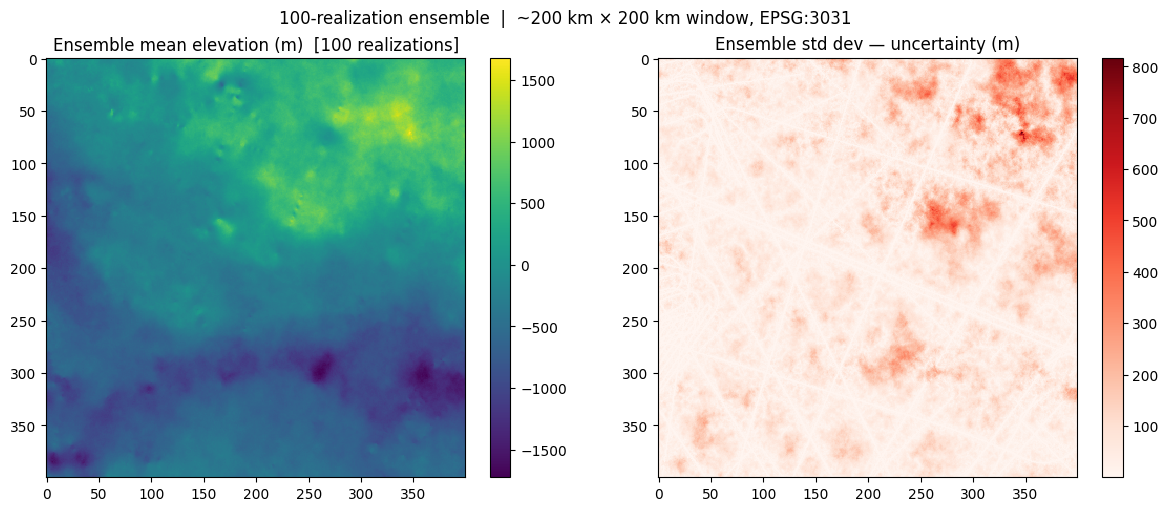


── 3. Transect interpolation ──
   Profile shape: (100, 40)  (realizations × points)


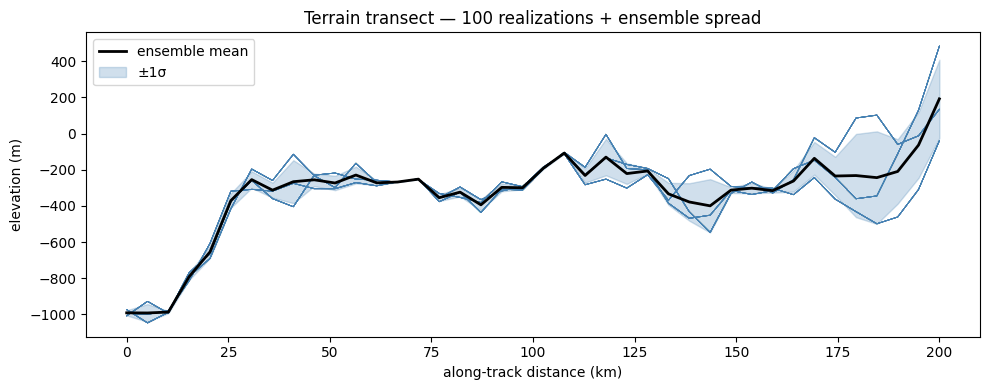

In [20]:
import icechunk, zarr, numpy as np, xarray as xr
import matplotlib.pyplot as plt

# ── Open the 100-realization store (read-only) ────────────────────────────────
storage_100  = icechunk.local_filesystem_storage(STORE_100_PATH)
repo_100_ro  = icechunk.Repository.open(storage_100)
session_100  = repo_100_ro.readonly_session("main")
ds_100       = xr.open_zarr(session_100.store, consolidated=False, zarr_format=3)
da_100       = ds_100.realizations

print(f"Store      : {STORE_100_PATH}")
print(f"Array shape: {da_100.shape}  (realizations × y × x)")
print(f"dtype      : {da_100.dtype}")
print(f"Coords     : x [{float(da_100.x.min()):.0f}, {float(da_100.x.max()):.0f}]  "
      f"y [{float(da_100.y.min()):.0f}, {float(da_100.y.max()):.0f}]")

# ── 1. Windowed read ──────────────────────────────────────────────────────────
# Fetch a ~200 km × 200 km window. Only the inner chunks overlapping this bbox
# are read — no full-array load.
x_min, x_max = -500_000.0, -300_000.0   # metres, EPSG:3031
y_max, y_min =  500_000.0,  300_000.0   # y is stored descending

subset = da_100.sel(x=slice(x_min, x_max), y=slice(y_max, y_min))
print(f"\n── 1. Windowed read ──")
print(f"   Subset shape      : {subset.shape}")
print(f"   Uncompressed size : {subset.nbytes / 1e6:.0f} MB")

# ── 2. Ensemble summary statistics ───────────────────────────────────────────
# mean  → best-estimate terrain for the window
# std   → per-pixel uncertainty across the 100-member ensemble
mean_elev = subset.mean(dim="i").compute()
std_elev  = subset.std(dim="i").compute()

print(f"\n── 2. Ensemble statistics (over window) ──")
print(f"   mean range: {float(mean_elev.min()):.2f} – {float(mean_elev.max()):.2f} m")
print(f"   std  range: {float(std_elev.min()):.2f}  – {float(std_elev.max()):.2f} m")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im1 = ax1.imshow(mean_elev.values, origin="upper", aspect="equal", interpolation="nearest")
ax1.set_title("Ensemble mean elevation (m)  [100 realizations]")
plt.colorbar(im1, ax=ax1)
im2 = ax2.imshow(std_elev.values, origin="upper", aspect="equal",
                 interpolation="nearest", cmap="Reds")
ax2.set_title("Ensemble std dev — uncertainty (m)")
plt.colorbar(im2, ax=ax2)
fig.suptitle("100-realization ensemble  |  ~200 km × 200 km window, EPSG:3031")
plt.show()

# ── 3. Transect interpolation ─────────────────────────────────────────────────
# Query all 100 realizations at 40 points along a horizontal transect.
# da.interp() fetches only the chunks that touch each sample location.
n_pts   = 40
track_x = xr.DataArray(np.linspace(x_min, x_max, n_pts), dims="points")
track_y = xr.DataArray(np.full(n_pts, (y_min + y_max) / 2.0), dims="points")

profile = da_100.interp(x=track_x, y=track_y, method="linear").compute()
print(f"\n── 3. Transect interpolation ──")
print(f"   Profile shape: {profile.shape}  (realizations × points)")

ens_mean = profile.mean("i")
ens_std  = profile.std("i")

# Along-track distance — works for any transect geometry, not just horizontal ones
dist_km = np.sqrt(
    (track_x.values - track_x.values[0]) ** 2 +
    (track_y.values - track_y.values[0]) ** 2
) / 1e3

fig, ax = plt.subplots(figsize=(10, 4))
for k in range(profile.sizes["i"]):
    ax.plot(dist_km, profile.isel(i=k).values,
            color="steelblue", alpha=0.25, linewidth=0.6)
ax.plot(dist_km, ens_mean.values,
        color="black", linewidth=2, label="ensemble mean")
ax.fill_between(
    dist_km,
    (ens_mean - ens_std).values,
    (ens_mean + ens_std).values,
    alpha=0.25, color="steelblue", label="±1σ",
)
ax.set_xlabel("along-track distance (km)")
ax.set_ylabel("elevation (m)")
ax.set_title("Terrain transect — 100 realizations + ensemble spread")
ax.legend()
plt.tight_layout()
plt.show()


## Summary

| Concern | Decision |
|---|---|
| dtype | `float32` — half the storage of float64 |
| Shard shape | `(N_realizations, 512, 512)` — ~100 MB at 100 realizations; all realizations written simultaneously per spatial tile |
| Inner chunk | `(N_realizations, 128, 128)` — ~6.5 MB per read (targeting 8 MB per AWS S3 best practices) |
| Partial update cost | Only shards overlapping the basin bounding box are rewritten |
| Update pattern | 20–25 glacier basins, each ~200–400 × 200–400 grid cells (~100 km); updates run from HPC then pushed to cloud |
| Store hosting | source.coop — cloud-native, supports incremental updates |
| User access | Xarray Python library handles subsetting; overviews for web visualisation are an additive objective |
| Snapshot pinning | `repository.readonly_session(snapshot_id=...)` — read any historical version |
| Ingestion trigger | Call `ingest()` (above) from CLI, cron, or CI when new `.npy` lands |
| Store API | `icechunk.local_filesystem_storage` / `icechunk.s3_storage` for cloud |